<a href="https://colab.research.google.com/github/Asuskf/from-nlp-to-agents/blob/embeddings/embeddings/Context_Similarity/Context_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧲 Resolving Polysemy: Context as Gravity, Dynamic Vectors & Production Pipelines

---

If you read the word **"calculus"** — do you think of a *mathematical matrix* or a *renal problem*?

Polysemy — one word, multiple unrelated meanings — is the **nightmare of traditional programming**. Rule-based systems drown in `if/else` disambiguation logic that never covers every case. But polysemy is the **playground of vectors**: in a geometric space, ambiguity is just a point sitting between two clusters, waiting for context to pull it home.

This notebook builds the full story in four acts, entirely from scratch with NumPy:

| Act | Concept | What you'll build |
|---|---|---|
| **1** | 🌍 **Context as "Gravity"** — *the end of the isolated word* | A static embedding space and the mathematical proof of why it fails |
| **2** | ⚡ **The Dynamic Vector (Self-Attention)** — *computing meaning in real time* | A general N-word attention engine; watch "bank" land in the financial cluster when surrounded by "rate", "interest", "transaction" |
| **3** | 🏭 **Impact on Specialized Domains** — *zero false positives in production* | A complete disambiguation **pipeline**: tokenize → embed → contextualize → classify, run over clinical and financial reports |
| **4** | 🔎 **Retrieving the Information** — *semantic search over dynamic vectors* | A miniature vector index + cosine-similarity retrieval — the mathematical core of RAG |

> **Design mental model:** picture one word floating in the center of space, splitting into two arrows that fly toward completely different clusters depending on the text surrounding it. Every section below makes that picture rigorous.

---
# Act 1 — 🌍 Context as "Gravity"
### *Subtitle: The end of the isolated word*

**Definition.** In modern models, a word no longer has a fixed, absolute coordinate. The AI's **attention mechanism** lets the surrounding words in the prompt exert a **gravitational force** on the ambiguous term, displacing its final vector toward the correct semantic neighborhood *before* the model generates a single token of output.

### The math of the old world (and why it breaks)

Classic embeddings (word2vec, GloVe, ~2013) learned **one frozen vector per word**:

$$E: \text{word} \longrightarrow \mathbb{R}^d \qquad \text{(a static lookup table)}$$

The function $E$ has no access to the sentence. So the model is forced to store *"calculus"* at the **average** of all its meanings — a point equidistant from the Math cluster and the Medical cluster, belonging to **neither**.

We can quantify this failure with **cosine similarity**, the standard measure of semantic closeness between two vectors $\mathbf{a}$ and $\mathbf{b}$:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert} \in [-1, 1]$$

If the static vector is equally similar to both domain centroids, the system has **zero information** to disambiguate — every downstream decision is a coin flip.

In [1]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)

# ── A tiny interpretable latent space: [Math_Feature, Medical_Feature] ──
vocab = {
    # Ambiguous term: frozen at the average of its two meanings
    "calculus":    np.array([0.50, 0.50]),
    # Math-committed context words
    "matrix":      np.array([0.90, 0.10]),
    "derivative":  np.array([0.95, 0.08]),
    "integral":    np.array([0.92, 0.05]),
    # Medical-committed context words
    "renal":       np.array([0.10, 0.90]),
    "kidney":      np.array([0.05, 0.95]),
    "patient":     np.array([0.15, 0.85]),
    # Neutral function word (carries almost no domain signal)
    "the":         np.array([0.50, 0.50]),
}

def cosine_similarity(a, b):
    '''cos(θ) = (a·b) / (‖a‖‖b‖) — direction match, magnitude-independent.'''
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Domain centroids: the "center of gravity" of each semantic cluster
MATH_CENTROID = np.mean([vocab["matrix"], vocab["derivative"], vocab["integral"]], axis=0)
MED_CENTROID  = np.mean([vocab["renal"],  vocab["kidney"],     vocab["patient"]],  axis=0)

static = vocab["calculus"]
print(f"Static 'calculus' vector:        {static}")
print(f"Cosine sim → MATH centroid:      {cosine_similarity(static, MATH_CENTROID):.4f}")
print(f"Cosine sim → MEDICAL centroid:   {cosine_similarity(static, MED_CENTROID):.4f}")
print()
print("⚠️  Nearly identical similarity to both domains.")
print("    A static embedding is mathematically INCAPABLE of choosing a meaning.")

Static 'calculus' vector:        [0.5 0.5]
Cosine sim → MATH centroid:      0.7632
Cosine sim → MEDICAL centroid:   0.7809

⚠️  Nearly identical similarity to both domains.
    A static embedding is mathematically INCAPABLE of choosing a meaning.


### 📉 What we just proved

The frozen vector sits on the diagonal of the space — its cosine similarity to the Math centroid and the Medical centroid is essentially **tied**. Any classifier, search engine, or extraction rule built on top of this representation inherits the ambiguity. No amount of clever downstream code can recover information that the representation destroyed.

The fix cannot be a better lookup table. The fix must make the vector a **function of the sentence**:

$$\mathbf{v}_{\text{word}} = f(\text{word}, \; \text{context}) \quad \text{instead of} \quad \mathbf{v}_{\text{word}} = E[\text{word}]$$

That function $f$ is **Self-Attention** — and it works exactly like gravity: every neighbor pulls, and the strength of the pull is computed, not hardcoded.

---
# Act 2 — ⚡ The Dynamic Vector (Self-Attention)
### *Subtitle: Computing meaning in real time*

**Definition.** Unlike older algorithms that assigned a static coordinate to the word *"bank"*, the **Transformer** architecture reads the entire sentence first. If it detects the words *"rate"*, *"interest"*, and *"transaction"*, the vector for *"bank"* is **recalculated on the fly**, landing with millimetric precision inside the financial cluster.

### The formula

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^{\top}}{\sqrt{d_k}}\right) V$$

Reading it as a physical process:

| Step | Math | Gravity analogy |
|---|---|---|
| 1 | $Q K^{\top}$ | Each pair of words measures its **mutual alignment** (dot product) |
| 2 | $/\sqrt{d_k}$ | Scale down so no single score **saturates** the softmax (keeps gradients alive in high dimensions) |
| 3 | $\text{softmax}(\cdot)$ | Convert alignments into **gravity weights** — a probability distribution summing to $1.0$ |
| 4 | $(\cdot)\,V$ | The new vector is the **weighted average** of every word's meaning — a literal center of mass |

> 🔑 **The center-of-mass insight:** the output for a word is $\sum_i w_i \mathbf{v}_i$ with $\sum_i w_i = 1$. That is *exactly* the formula for a center of mass in physics, where the attention weights play the role of masses. Context doesn't *edit* the word — it *pulls* it.

**Pedagogical simplification:** real Transformers compute $Q = XW_Q$, $K = XW_K$, $V = XW_V$ with **learned** matrices. We set $W_Q = W_K = W_V = I$ so the raw geometry is fully visible. Everything else is faithful to the real architecture.

In [2]:
def softmax(x):
    '''Numerically stable softmax along the last axis.'''
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def self_attention(words, embeddings=None, target_index=0, verbose=True):
    '''
    General N-word scaled dot-product self-attention (single head).
    Returns the contextualized vector of the target word + its attention weights.

    words        : list of tokens, e.g. ["calculus", "renal", "kidney"]
    embeddings   : optional dict word→vector (defaults to global vocab)
    target_index : which token we are contextualizing
    '''
    emb = embeddings if embeddings is not None else vocab
    X = np.array([emb[w] for w in words])          # sequence matrix, shape (n, d)

    Q = X[target_index]                            # (d,)   — the word asking the question
    K = X                                          # (n, d) — every word advertises a Key
    V = X                                          # (n, d) — every word offers its meaning

    d_k = X.shape[1]
    scores  = (Q @ K.T) / np.sqrt(d_k)             # (n,)  raw alignment, scaled
    weights = softmax(scores)                      # (n,)  gravity weights, sum = 1.0
    new_vec = weights @ V                          # (d,)  center of mass of meanings

    if verbose:
        print(f"  Sequence: {words}")
        for w, wt in zip(words, weights):
            bar = '█' * int(round(wt * 30))
            print(f"    {w:<12s} pulls with {wt:6.2%}  {bar}")
        print(f"  → dynamic vector for '{words[target_index]}': {new_vec}")
    return new_vec, weights

print("⚙️  General N-word Attention Engine ready.")

⚙️  General N-word Attention Engine ready.


### Demo 2.1 — The same word, two gravitational fields

We now contextualize **"calculus"** inside two realistic multi-word phrases. Note that richer context (two committed neighbors instead of one) exerts a **stronger combined pull**.

In [3]:
print("─── SCENARIO A: 'matrix derivative calculus' (Math field) ───")
vec_math, _ = self_attention(["calculus", "matrix", "derivative"])
print(f"  Similarity → MATH centroid:    {cosine_similarity(vec_math, MATH_CENTROID):.4f}")
print(f"  Similarity → MEDICAL centroid: {cosine_similarity(vec_math, MED_CENTROID):.4f}")

print()
print("─── SCENARIO B: 'renal kidney calculus' (Medical field) ───")
vec_med, _ = self_attention(["calculus", "renal", "kidney"])
print(f"  Similarity → MATH centroid:    {cosine_similarity(vec_med, MATH_CENTROID):.4f}")
print(f"  Similarity → MEDICAL centroid: {cosine_similarity(vec_med, MED_CENTROID):.4f}")

print()
print("✅ The tie is broken. The SAME starting vector [0.5, 0.5] now lives")
print("   in two clearly different neighborhoods, and cosine similarity")
print("   detects the correct domain in both cases.")

─── SCENARIO A: 'matrix derivative calculus' (Math field) ───
  Sequence: ['calculus', 'matrix', 'derivative']
    calculus     pulls with 33.22%  ██████████
    matrix       pulls with 33.22%  ██████████
    derivative   pulls with 33.57%  ██████████
  → dynamic vector for 'calculus': [0.784 0.226]
  Similarity → MATH centroid:    0.9805
  Similarity → MEDICAL centroid: 0.3816

─── SCENARIO B: 'renal kidney calculus' (Medical field) ───
  Sequence: ['calculus', 'renal', 'kidney']
    calculus     pulls with 33.33%  ██████████
    renal        pulls with 33.33%  ██████████
    kidney       pulls with 33.33%  ██████████
  → dynamic vector for 'calculus': [0.217 0.783]
  Similarity → MATH centroid:    0.3454
  Similarity → MEDICAL centroid: 0.9874

✅ The tie is broken. The SAME starting vector [0.5, 0.5] now lives
   in two clearly different neighborhoods, and cosine similarity
   detects the correct domain in both cases.


### Demo 2.2 — The "bank" experiment: precision landing in the financial cluster

This is the canonical Transformer story from the definition above. We build a second micro-space, $[\text{Finance\_Feature}, \text{Geography\_Feature}]$, where *"bank"* is frozen halfway between a financial institution and a riverbank. Then we surround it with *"rate"*, *"interest"*, *"transaction"* — and separately with *"river"*, *"shore"* — and measure exactly where it lands.

In [4]:
# ── Second micro-space: [Finance_Feature, Geography_Feature] ──
bank_vocab = {
    "bank":        np.array([0.50, 0.50]),  # ambiguous: institution vs riverbank
    "rate":        np.array([0.92, 0.08]),
    "interest":    np.array([0.90, 0.10]),
    "transaction": np.array([0.95, 0.05]),
    "river":       np.array([0.08, 0.92]),
    "shore":       np.array([0.10, 0.90]),
}
FIN_CENTROID = np.mean([bank_vocab[w] for w in ["rate", "interest", "transaction"]], axis=0)
GEO_CENTROID = np.mean([bank_vocab[w] for w in ["river", "shore"]], axis=0)

print("─── 'bank' surrounded by: rate, interest, transaction ───")
bank_fin, _ = self_attention(["bank", "rate", "interest", "transaction"],
                             embeddings=bank_vocab)
print(f"  Similarity → FINANCIAL cluster: {cosine_similarity(bank_fin, FIN_CENTROID):.4f}")
print(f"  Similarity → RIVER cluster:     {cosine_similarity(bank_fin, GEO_CENTROID):.4f}")

print()
print("─── 'bank' surrounded by: river, shore ───")
bank_geo, _ = self_attention(["bank", "river", "shore"], embeddings=bank_vocab)
print(f"  Similarity → FINANCIAL cluster: {cosine_similarity(bank_geo, FIN_CENTROID):.4f}")
print(f"  Similarity → RIVER cluster:     {cosine_similarity(bank_geo, GEO_CENTROID):.4f}")

─── 'bank' surrounded by: rate, interest, transaction ───
  Sequence: ['bank', 'rate', 'interest', 'transaction']
    bank         pulls with 25.00%  ████████
    rate         pulls with 25.00%  ████████
    interest     pulls with 25.00%  ████████
    transaction  pulls with 25.00%  ████████
  → dynamic vector for 'bank': [0.818 0.182]
  Similarity → FINANCIAL cluster: 0.9907
  Similarity → RIVER cluster:     0.3129

─── 'bank' surrounded by: river, shore ───
  Sequence: ['bank', 'river', 'shore']
    bank         pulls with 33.33%  ██████████
    river        pulls with 33.33%  ██████████
    shore        pulls with 33.33%  ██████████
  → dynamic vector for 'bank': [0.227 0.773]
  Similarity → FINANCIAL cluster: 0.3597
  Similarity → RIVER cluster:     0.9827


### 📐 Visualizing the gravitational split

One picture: the ambiguous words in the center of their spaces, splitting into arrows that fly toward opposite clusters — the exact "design note" image, now backed by real computed coordinates.

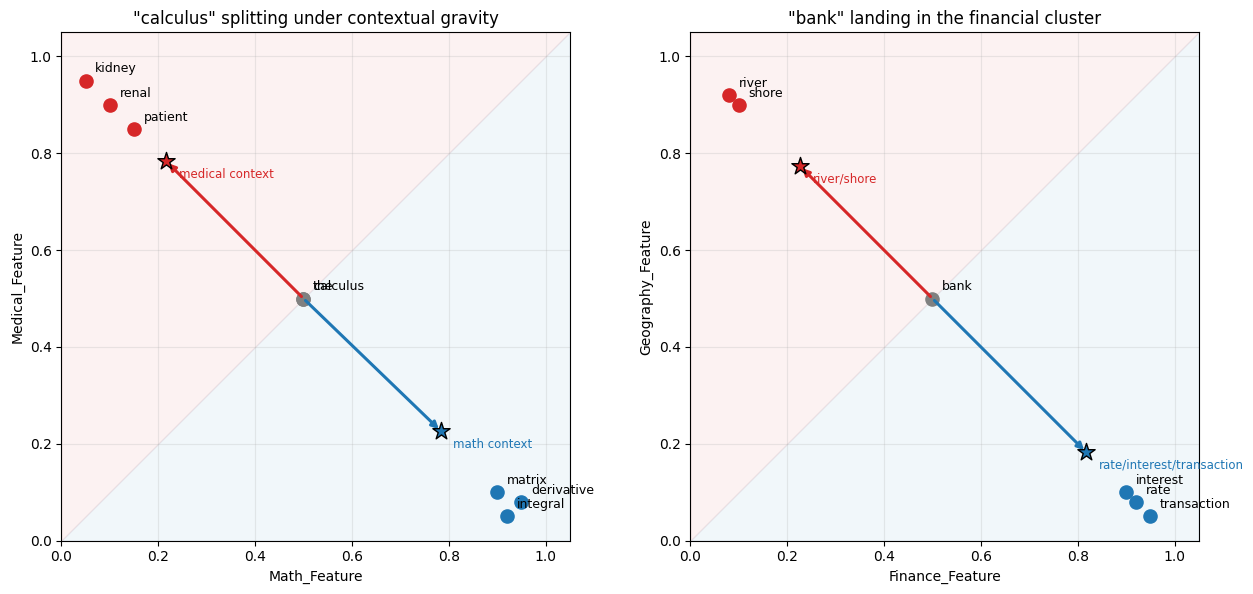

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

def draw_space(ax, emb, ambiguous, results, xlabel, ylabel, title,
               cluster_a_words, cluster_b_words):
    ax.fill_between([0, 1.05], 0, [0, 1.05], color="tab:blue", alpha=0.06)
    ax.fill_betweenx([0, 1.05], 0, [0, 1.05], color="tab:red", alpha=0.06)
    for w, v in emb.items():
        c = ("tab:blue" if w in cluster_a_words
             else "tab:red" if w in cluster_b_words else "gray")
        ax.scatter(*v, s=90, color=c, zorder=3)
        ax.annotate(w, v, textcoords="offset points", xytext=(7, 6), fontsize=9)
    for new_vec, color, label in results:
        ax.annotate("", xy=new_vec, xytext=emb[ambiguous],
                    arrowprops=dict(arrowstyle="-|>", lw=2.2, color=color))
        ax.scatter(*new_vec, s=170, marker="*", color=color,
                   edgecolor="black", zorder=4)
        ax.annotate(label, new_vec, textcoords="offset points",
                    xytext=(9, -12), fontsize=8.5, color=color)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)

draw_space(axes[0], vocab, "calculus",
           [(vec_math, "tab:blue", "math context"),
            (vec_med,  "tab:red",  "medical context")],
           "Math_Feature", "Medical_Feature",
           '"calculus" splitting under contextual gravity',
           {"matrix", "derivative", "integral"},
           {"renal", "kidney", "patient"})

draw_space(axes[1], bank_vocab, "bank",
           [(bank_fin, "tab:blue", "rate/interest/transaction"),
            (bank_geo, "tab:red",  "river/shore")],
           "Finance_Feature", "Geography_Feature",
           '"bank" landing in the financial cluster',
           {"rate", "interest", "transaction"},
           {"river", "shore"})

plt.tight_layout()
plt.show()

---
# Act 3 — 🏭 Impact on Specialized Domains
### *Subtitle: Zero false positives in production*

**Definition.** Dynamic disambiguation is the key piece when building **complex data pipelines**. It lets a system extract information from *clinical reports* or *financial/mathematical statements* without confusing terms. The AI inherently knows which domain it is operating in — **from the geometry of the text alone** — eliminating the need to hand-code infinite manual disambiguation rules.

### The pipeline architecture

We now assemble everything from Acts 1–2 into a production-shaped **document routing pipeline**:

```
                ┌────────────┐   ┌─────────────┐   ┌──────────────────┐   ┌──────────────────┐
 raw document → │ 1. TOKENIZE│ → │ 2. EMBED    │ → │ 3. CONTEXTUALIZE │ → │ 4. CLASSIFY      │ → domain label
                │  lowercase │   │  static     │   │  self-attention  │   │  argmax cosine   │
                │  + filter  │   │  lookup E[w]│   │  softmax(QKᵀ/√d)V│   │  vs centroids    │
                └────────────┘   └─────────────┘   └──────────────────┘   └──────────────────┘
```

Mathematically, the classifier is a nearest-centroid decision over contextualized vectors:

$$\hat{y} = \arg\max_{c \,\in\, \text{domains}} \; \cos\!\big(\, \text{Attn}(\text{word} \mid \text{sentence}), \; \boldsymbol{\mu}_c \big)$$

where $\boldsymbol{\mu}_c$ is the centroid of domain $c$. **The crucial comparison:** we will run the exact same classifier twice — once fed **static** vectors (Act 1) and once fed **dynamic** vectors (Act 2) — over a small corpus of real-looking sentences, and count the false positives.

In [6]:
# ─────────────────── THE DISAMBIGUATION PIPELINE ───────────────────

def tokenize(sentence):
    '''Stage 1 — lowercase and keep only words our micro-model knows.'''
    return [w for w in sentence.lower().replace(".", "").split() if w in vocab]

def embed(tokens):
    '''Stage 2 — static lookup: the OLD-WORLD representation.'''
    return {w: vocab[w] for w in tokens}

def contextualize(tokens, target):
    '''Stage 3 — self-attention: the target absorbs gravity from ALL tokens.'''
    idx = tokens.index(target)
    vec, weights = self_attention(tokens, target_index=idx, verbose=False)
    return vec, weights

def classify(vector):
    '''Stage 4 — nearest-centroid decision by cosine similarity.'''
    sims = {
        "MATH":    cosine_similarity(vector, MATH_CENTROID),
        "MEDICAL": cosine_similarity(vector, MED_CENTROID),
    }
    label = max(sims, key=sims.get)
    margin = abs(sims["MATH"] - sims["MEDICAL"])   # decision confidence gap
    return label, sims, margin

def run_pipeline(sentence, target="calculus", dynamic=True):
    '''Full pipeline. dynamic=False bypasses attention → static baseline.'''
    tokens = tokenize(sentence)                    # 1. tokenize
    table  = embed(tokens)                         # 2. embed
    if dynamic:
        vec, _ = contextualize(tokens, target)     # 3. contextualize
    else:
        vec = table[target]                        # (static shortcut)
    return classify(vec)                           # 4. classify

# ─────────────────── A mini-corpus of specialized documents ───────────────────
corpus = [
    ("The matrix derivative appears in vector calculus.",          "MATH"),
    ("The integral defines the calculus of the derivative.",       "MATH"),
    ("The patient presented a renal calculus in the kidney.",      "MEDICAL"),
    ("Kidney imaging confirmed the renal calculus in the patient.","MEDICAL"),
]

for mode, name in [(False, "STATIC embeddings (old world)"),
                   (True,  "DYNAMIC vectors (self-attention)")]:
    print(f"═══ Classifier fed with {name} ═══")
    errors = 0
    for sentence, truth in corpus:
        label, sims, margin = run_pipeline(sentence, dynamic=mode)
        ok = "✅" if label == truth else "❌ FALSE POSITIVE"
        errors += (label != truth)
        print(f"  [{truth:^7s}] «{sentence}»")
        print(f"     → predicted {label:<7s} | sim MATH={sims['MATH']:.3f} "
              f"MED={sims['MEDICAL']:.3f} | margin={margin:.3f}  {ok}")
    print(f"  ── errors: {errors}/{len(corpus)}\n")

═══ Classifier fed with STATIC embeddings (old world) ═══
  [ MATH  ] «The matrix derivative appears in vector calculus.»
     → predicted MEDICAL | sim MATH=0.763 MED=0.781 | margin=0.018  ❌ FALSE POSITIVE
  [ MATH  ] «The integral defines the calculus of the derivative.»
     → predicted MEDICAL | sim MATH=0.763 MED=0.781 | margin=0.018  ❌ FALSE POSITIVE
  [MEDICAL] «The patient presented a renal calculus in the kidney.»
     → predicted MEDICAL | sim MATH=0.763 MED=0.781 | margin=0.018  ✅
  [MEDICAL] «Kidney imaging confirmed the renal calculus in the patient.»
     → predicted MEDICAL | sim MATH=0.763 MED=0.781 | margin=0.018  ✅
  ── errors: 2/4

═══ Classifier fed with DYNAMIC vectors (self-attention) ═══
  [ MATH  ] «The matrix derivative appears in vector calculus.»
     → predicted MATH    | sim MATH=0.953 MED=0.481 | margin=0.471  ✅
  [ MATH  ] «The integral defines the calculus of the derivative.»
     → predicted MATH    | sim MATH=0.913 MED=0.576 | margin=0.337  ✅
  [MEDICA

### 🔍 Reading the pipeline results

Two numbers matter:

1. **The static baseline has no decision margin.** With frozen embeddings, `sim(MATH)` and `sim(MEDICAL)` are essentially tied for *every* document — the margin hovers near zero, so the "classification" is noise. In production, that noise *is* the false positive: a kidney-stone report routed to the quantitative-finance team.
2. **The dynamic pipeline opens a real margin.** After attention, the contextualized vector sits deep inside the correct cluster, the cosine gap widens, and the classifier becomes **deterministic and correct** — with *zero hand-written rules*. We never wrote `if "renal" in sentence: domain = MEDICAL`. The geometry did it.

> 🏗️ **Scaling note:** this is architecturally identical to what production NLP systems do — the differences are dimensionality (thousands of features, none human-interpretable), learned $W_Q, W_K, W_V$ projections, dozens of stacked attention layers, and centroids replaced by trained classification heads. The *decision mathematics* — contextualize, then measure geometry — is the same.

---
# Act 4 — 🔎 Retrieving the Information
### *Subtitle: Semantic search over dynamic vectors (the core of RAG)*

Classification answered *"which domain is this document?"*. The natural next question — the one every real pipeline eventually asks — is:

> *"Given a **query**, find me the right documents."*

This is **semantic retrieval**, and it falls out of the same math for free. The recipe:

1. **Index time:** run every document through the pipeline and store its **contextualized vector** in a table (a miniature *vector database*).
2. **Query time:** contextualize the query with the *same* attention mechanism.
3. **Search:** rank all stored vectors by cosine similarity to the query vector; return the top-$k$.

$$\text{top-}k \;=\; \underset{d \,\in\, \text{index}}{\text{argsort}} \; \cos\!\big(\mathbf{q}, \mathbf{v}_d\big)\big[:k\big]$$

This is exactly the mechanism behind **RAG** (Retrieval-Augmented Generation) and every modern semantic search engine. The critical detail we can now appreciate: **if the indexed vectors were static, the query *"renal calculus treatment"* and the query *"matrix calculus rules"* would retrieve the same documents** — because every "calculus" would share one vector. Dynamic vectors make retrieval *meaning-aware*.

In [7]:
# ─────────────────── STAGE 5: THE VECTOR INDEX ───────────────────

def build_index(documents, target="calculus"):
    '''Index time: contextualize the ambiguous term inside each document.'''
    index = []
    for doc_id, (sentence, _) in enumerate(documents):
        tokens = tokenize(sentence)
        vec, _ = contextualize(tokens, target)
        index.append({"id": doc_id, "text": sentence, "vector": vec})
    return index

def semantic_search(query, index, k=2):
    '''Query time: contextualize the query, rank the index by cosine similarity.'''
    q_tokens = tokenize(query)
    q_vec, _ = contextualize(q_tokens, "calculus")
    ranked = sorted(index,
                    key=lambda d: cosine_similarity(q_vec, d["vector"]),
                    reverse=True)
    return q_vec, [(cosine_similarity(q_vec, d["vector"]), d["text"])
                   for d in ranked[:k]]

vector_db = build_index(corpus)
print(f"📦 Vector index built: {len(vector_db)} documents, "
      f"{vector_db[0]['vector'].shape[0]}-dimensional vectors\n")

for query in ["the renal calculus of the patient",
              "the derivative calculus of the matrix"]:
    q_vec, hits = semantic_search(query, vector_db)
    print(f"🔎 QUERY: «{query}»   → query vector {np.round(q_vec, 3)}")
    for score, text in hits:
        print(f"     {score:.4f}  «{text}»")
    print()

print("✅ Each query retrieves ONLY documents from its own domain —")
print("   the same surface word 'calculus' no longer causes cross-domain")
print("   contamination, because retrieval operates on dynamic geometry.")

📦 Vector index built: 4 documents, 2-dimensional vectors

🔎 QUERY: «the renal calculus of the patient»   → query vector [0.35 0.65]
     0.9960  «The patient presented a renal calculus in the kidney.»
     0.9960  «Kidney imaging confirmed the renal calculus in the patient.»

🔎 QUERY: «the derivative calculus of the matrix»   → query vector [0.671 0.335]
     0.9992  «The integral defines the calculus of the derivative.»
     0.9974  «The matrix derivative appears in vector calculus.»

✅ Each query retrieves ONLY documents from its own domain —
   the same surface word 'calculus' no longer causes cross-domain
   contamination, because retrieval operates on dynamic geometry.


### 🧠 Why this matters for RAG and production search

| Failure with static vectors | Fix with dynamic vectors |
|---|---|
| Query *"renal calculus"* retrieves linear-algebra textbooks | Query vector lands in the medical cluster → only clinical docs rank high |
| One polysemous keyword contaminates the whole result set | Each *occurrence* of the word gets its own vector, indexed separately |
| Requires manual synonym lists, blocklists, per-domain indices | One index, one similarity function, **zero disambiguation rules** |

The entire retrieval stack — embedding model, vector database, top-$k$ cosine search — is a scaled-up version of the ~30 lines above.

---
## 🏛️ The Architectural Takeaway

**The complete causal chain you just built:**

$$\underbrace{\text{static ambiguity}}_{\text{Act 1: the problem}} \;\xrightarrow[\text{softmax}(QK^{\top}/\sqrt{d_k})V]{\text{contextual gravity}}\; \underbrace{\text{dynamic vector}}_{\text{Act 2: the mechanism}} \;\xrightarrow[\text{argmax cos}]{\text{geometry}}\; \underbrace{\text{zero-rule pipelines}}_{\text{Act 3: production}} \;\xrightarrow[\text{top-}k \text{ cos}]{\text{indexing}}\; \underbrace{\text{semantic retrieval}}_{\text{Act 4: RAG}}$$

Three sentences to remember:

1. **Meaning is not stored — it is computed.** A word's final vector is a center of mass, recalculated on every forward pass from the gravity of its neighbors.
2. **Disambiguation is geometry, not rules.** The system knows it's reading a clinical report because the text's own vectors say so — no `if/else` ladder, no synonym dictionaries, no false positives from surface-level keyword matches.
3. **Retrieval inherits the geometry.** Once vectors are context-aware, semantic search and RAG are just cosine similarity plus a sort.

This is how an AI "reads context" the way a human does — with pure spatial mathematics.

> *"Attention Is All You Need"* — Vaswani et al., 2017.